### Web Scraping:

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# Base URL
base_url = "http://books.toscrape.com/catalogue/page-{}.html"

all_data = []

# Loop through multiple pages
for page in range(1, 51):   # scrape first 5 pages
    print(f"Scraping page {page}...")
    
    url = base_url.format(page)
    
    response = requests.get(url)
    response.encoding = "utf-8"   # Fix encoding issue
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.find_all("article", class_="product_pod")
    
    for book in books:
        # Title
        title = book.h3.a["title"]
        
        # Price (raw)
        price = book.find("p", class_="price_color").text
        
        # Rating (text → number)
        rating_class = book.find("p", class_="star-rating")["class"]
        rating_text = rating_class[1]
        
        rating_map = {
            "One": 1,
            "Two": 2,
            "Three": 3,
            "Four": 4,
            "Five": 5
        }
        
        rating = rating_map.get(rating_text, 0)
        
        # Availability
        availability = book.find("p", class_="instock availability").text.strip()
        
        # Product link
        link = book.h3.a["href"]
        full_link = "http://books.toscrape.com/catalogue/" + link
        
        # Append data
        all_data.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "Product Link": full_link
        })
    
    time.sleep(1)  # polite delay

# Create DataFrame
df = pd.DataFrame(all_data)

# Clean Price column (robust fix)
df["Price"] = df["Price"].str.replace(r"[^\d.]", "", regex=True).astype(float)

# Save to CSV
df.to_csv("books_data.csv", index=False)

print("✅ Scraping completed! Data saved as books_data.csv")

# -----------------------------
# 📊 Basic Analysis (Bonus)
# -----------------------------

print("\nTop 5 Most Expensive Books:")
print(df.sort_values(by="Price", ascending=False).head())

print("\nRating Distribution:")
print(df["Rating"].value_counts())

print("\nAverage Price:", df["Price"].mean())

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Scraping page 36...
Scraping page 37...
Scraping page 38...
Scraping page 39...
Scraping page 40...
Scraping page 41...
Scraping page 42...
Scraping page 43...
Scraping page 44...
Scraping page 45...
Scraping page 46...
Scraping page 47...
Scraping page 48...
Scraping page 49...
Scraping page 50...
✅ Scrapin

### DataSet:

In [7]:
df.head()

,Title,Price,Rating,Availability,Product Link
0,A Light in the Attic,51.77,3,In stock,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,1,In stock,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,1,In stock,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,4,In stock,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,http://books.toscrape.com/catalogue/sapiens-a-...


### Business Problem: 

An e-commerce company wants to understand how product pricing and ratings impact sales potential and customer satisfaction, in order to optimize pricing strategy and improve product offerings.

- Identify optimal price range for higher-rated products
- Understand relationship between price & ratings
- Find top-performing products
- Improve inventory and pricing decisions

In [8]:
df.shape

(1000, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   object 
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   object 
 4   Product Link  1000 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 39.2+ KB


In [12]:
df.describe()

,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


### Importing Libraries:

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Data Understannding:

<Axes: xlabel='Price', ylabel='Count'>

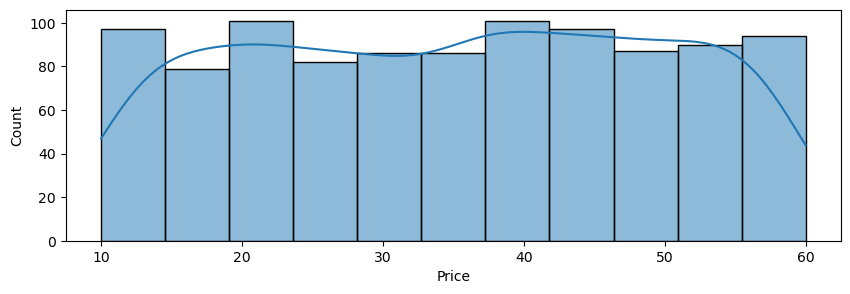

In [25]:
plt.figure(figsize=(10,3))
sns.histplot(df["Price"], kde=True)

In [26]:
df["Rating"].value_counts()

Rating
1    226
3    203
5    196
2    196
4    179
Name: count, dtype: int64

In [27]:
df["Availability"].value_counts()

Availability
In stock    1000
Name: count, dtype: int64

All the products are in Stocks so there is no point of keeping availability columns. Let's Drop it 

In [33]:
df.drop(columns= "Availability", inplace = True)

In [34]:
df.isnull().sum()

Title           0
Price           0
Rating          0
Product Link    0
dtype: int64

In [35]:
df.duplicated().sum()

0

<Axes: >

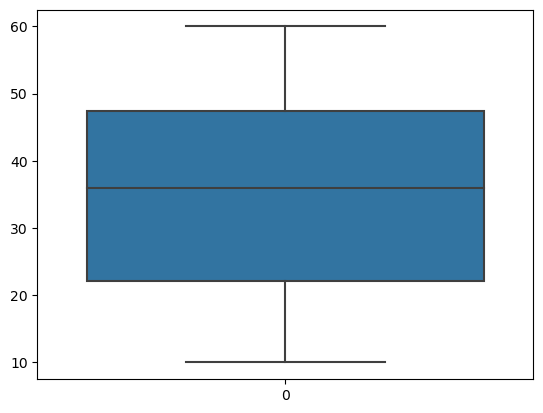

In [36]:
sns.boxplot(df["Price"])

No Outlier

In [38]:
df.head()

,Title,Price,Rating,Product Link
0,A Light in the Attic,51.77,3,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,1,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,1,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,4,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,5,http://books.toscrape.com/catalogue/sapiens-a-...


In [42]:
def rating_category(i):
    if i in [1, 2]:
        return "Poor"
    elif i == 3:
        return "Average"
    elif i == 4:
        return "Good"
    else:
        return "Excellent"

df["Rating Category"] = df["Rating"].apply(rating_category)

In [43]:
df.head()

,Title,Price,Rating,Product Link,Rating Category
0,A Light in the Attic,51.77,3,http://books.toscrape.com/catalogue/a-light-in...,Average
1,Tipping the Velvet,53.74,1,http://books.toscrape.com/catalogue/tipping-th...,Poor
2,Soumission,50.10,1,http://books.toscrape.com/catalogue/soumission...,Poor
3,Sharp Objects,47.82,4,http://books.toscrape.com/catalogue/sharp-obje...,Good
4,Sapiens: A Brief History of Humankind,54.23,5,http://books.toscrape.com/catalogue/sapiens-a-...,Excellent


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            1000 non-null   object 
 1   Price            1000 non-null   float64
 2   Rating           1000 non-null   int64  
 3   Product Link     1000 non-null   object 
 4   Rating Category  1000 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 39.2+ KB


 ### Exploratory Data Analysis:

#### How are products distributed across different price ranges?

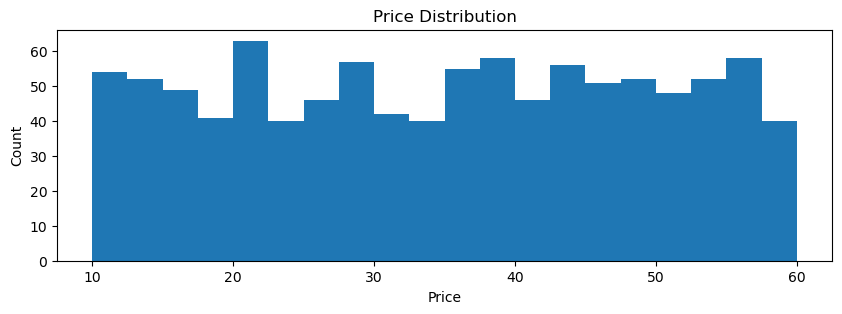

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.hist(df["Price"], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

- Products are spread across all price ranges rather than concentrated in one segment.
- Prices range roughly from 10 to 60
- Pricing is consistent and controlled, with no abnormal or extreme product pricing.

#### Rating Analysis

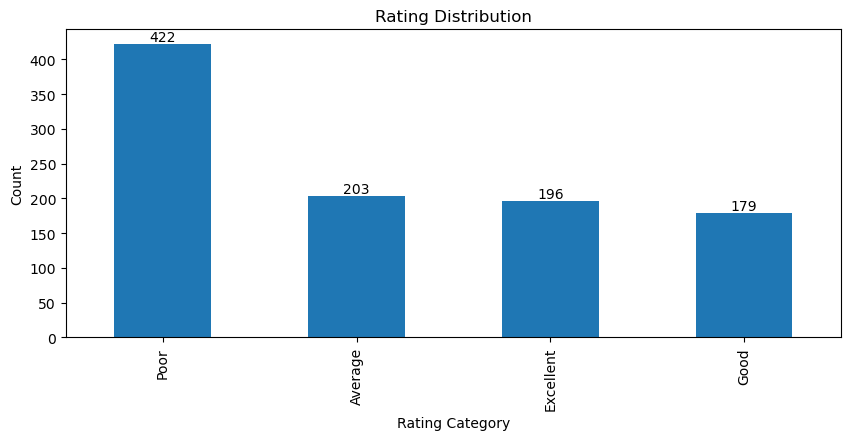

In [55]:
plt.figure(figsize=(10,4))

ax = df["Rating Category"].value_counts().plot(kind="bar")

# Add value labels
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2,   # x position
            i.get_height(),               # y position
            str(int(i.get_height())),     # value
            ha='center', va='bottom')

plt.title("Rating Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Count")

plt.show()

- A large portion of products are poorly rated, indicating low customer satisfaction and potential quality issues.
- The company is facing low overall product satisfaction, with a significant number of poorly rated products affecting customer experience and potential sales.
- Improve Low-Rated Products, Improves customer satisfaction & reduces negative reviews
- Promote High-Rated Products, Highlight Excellent (5-star) products, Feature them on homepage / recommendations. This will Boosts conversions & builds trust

#### Price vs Rating Distribution

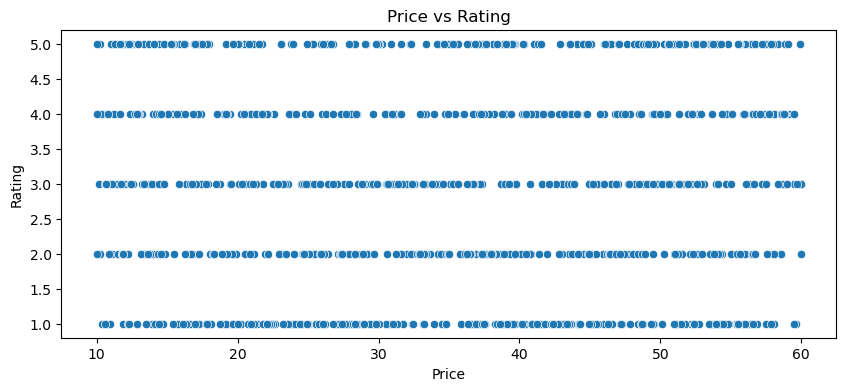

In [66]:
plt.figure(figsize=(10,4))
sns.scatterplot(x = df["Price"], y= df["Rating"])

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

The scatter plot indicates no significant correlation between price and rating, suggesting that product pricing is not aligned with perceived customer value. This highlights inefficiencies in pricing strategy and opportunities for better price-quality alignment

- Increase price for high-rated products
- Reduce price or improve low-rated expensive products
- Biggest problem: High price + low rating = customer dissatisfaction
- High rating + low/medium price, Use for marketing: “Best quality at affordable price”

#### Top 10 Best Value Products thats need to be featured, maintain inventory and run ads

In [68]:
best_value = df[(df["Rating"] >= 4) & (df["Price"] < df["Price"].median())]
best_value.sort_values(by="Rating", ascending=False).head(10)

,Title,Price,Rating,Product Link,Rating Category
999,"1,000 Places to See Before You Die",26.08,5,http://books.toscrape.com/catalogue/1000-place...,Excellent
883,A Visit from the Goon Squad,14.08,5,http://books.toscrape.com/catalogue/a-visit-fr...,Excellent
494,What Happened on Beale Street (Secrets of the ...,25.37,5,http://books.toscrape.com/catalogue/what-happe...,Excellent
470,Les Fleurs du Mal,29.04,5,http://books.toscrape.com/catalogue/les-fleurs...,Excellent
784,"Saga, Volume 3 (Saga (Collected Editions) #3)",21.57,5,http://books.toscrape.com/catalogue/saga-volum...,Excellent
460,Roller Girl,14.10,5,http://books.toscrape.com/catalogue/roller-gir...,Excellent
837,Gratitude,26.66,5,http://books.toscrape.com/catalogue/gratitude_...,Excellent
416,A Gentleman's Position (Society of Gentlemen #3),14.75,5,http://books.toscrape.com/catalogue/a-gentlema...,Excellent
414,Adultery,20.88,5,http://books.toscrape.com/catalogue/adultery_5...,Excellent
412,Born for This: How to Find the Work You Were M...,21.59,5,http://books.toscrape.com/catalogue/born-for-t...,Excellent


Identified products that deliver high customer satisfaction at lower prices.

#### Top 10 Worst Value Products that needs to be improved

In [73]:
Worst_value_product = df[(df["Rating"]<3) & (df["Price"]<df["Price"].median())]
Worst_value_product.sort_values(by="Rating", ascending=False).head(10)

,Title,Price,Rating,Product Link,Rating Category
530,How to Be a Domestic Goddess: Baking and the A...,28.25,2,http://books.toscrape.com/catalogue/how-to-be-...,Poor
468,"Love That Boy: What Two Presidents, Eight Road...",25.06,2,http://books.toscrape.com/catalogue/love-that-...,Poor
773,"Surely You're Joking, Mr. Feynman!: Adventures...",25.83,2,http://books.toscrape.com/catalogue/surely-you...,Poor
444,23 Degrees South: A Tropical Tale of Changing ...,35.79,2,http://books.toscrape.com/catalogue/23-degrees...,Poor
440,Chernobyl 01:23:40: The Incredible True Story ...,35.92,2,http://books.toscrape.com/catalogue/chernobyl-...,Poor
778,Soldier (Talon #3),24.72,2,http://books.toscrape.com/catalogue/soldier-ta...,Poor
798,Orange Is the New Black,24.61,2,http://books.toscrape.com/catalogue/orange-is-...,Poor
427,The Flowers Lied,16.68,2,http://books.toscrape.com/catalogue/the-flower...,Poor
799,One for the Money (Stephanie Plum #1),32.87,2,http://books.toscrape.com/catalogue/one-for-th...,Poor
423,Underlying Notes,11.82,2,http://books.toscrape.com/catalogue/underlying...,Poor


- Insight: These products are overpriced relative to their quality.
- Business Use: Reduce price, Improve quality Or remove them

### Key Insights:

- A significant portion of products fall under low (poor) ratings, indicating widespread customer dissatisfaction.
- Product ratings are mostly concentrated around average levels, with fewer high-performing (excellent) products.
- The price distribution is uniform, meaning the platform targets multiple customer segments without a dominant pricing tier.
- There is no strong correlation between price and rating, showing that higher prices do not guarantee better quality.
- Presence of high-rated low-price products suggests strong opportunities for “value-for-money” offerings.
- Existence of high-priced low-rated products highlights pricing inefficiencies and poor product positioning.
- Pricing lacks clear differentiation, making it difficult for customers to identify premium vs budget products.
- Overall dataset indicates a misalignment between pricing strategy and customer satisfaction.

### Business Decisions:

- Improve Low-Rated Products: Invest in product improvement or remove underperforming items
- Increase price of high-rated products AND Decrease price of low-rated expensive products
- Promote High-Performing Products, Feature them in recommendations, ads, homepage
- Introduce Quality Control System

#### Business Impact

- Increased Customer Satisfaction, Improved user trust and repeat purchases
- Higher Revenue & Conversions
- Better Product Positioning
- Reduced Negative Reviews

The analysis identified a clear misalignment between pricing and customer satisfaction. By implementing value-based pricing, improving low-performing products, and promoting high-value offerings, the business can enhance customer experience, increase conversions, and drive sustainable growth.

Delivered actionable insights on pricing inefficiencies and product quality gaps, enabling data-driven decisions to improve customer satisfaction and revenue